# Deliverable 2: Cross Entropy Method on CartPole

This notebook implements CEM from scratch and applies it to CartPole with a linear feedback policy.

Submission evidence produced here:

- CEM code
- batched MJX evaluation of policy samples
- elite selection and Gaussian refit
- reward-vs-iteration learning curve
- optional video of the best policy


In [ ]:
!pip -q install mujoco mujoco-mjx mediapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 110.6 MB/s eta 0:00:00


In [ ]:
import os
os.environ["MUJOCO_GL"] = "egl"

import time
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import lax, random

import mujoco
from mujoco import mjx
import mediapy as media

print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'
JAX backend: gpu
JAX devices: [CudaDevice(id=0)]


In [ ]:
# CartPole model directly in MuJoCo XML
cartpole_xml = """
<mujoco model="cartpole">
  <compiler coordinate="local" inertiafromgeom="true"/>
  <option timestep="0.01" gravity="0 0 -9.81"/>
  <worldbody>
    <light pos="0 0 3" dir="0 0 -1"/>
    <geom name="floor" type="plane" size="2 2 0.1" rgba="0.8 0.9 0.8 1"/>
    <body name="cart" pos="0 0 0.2">
      <joint name="slider" type="slide" axis="1 0 0" range="-1.5 1.5" limited="true"/>
      <geom name="cart_geom" type="box" size="0.2 0.15 0.1" rgba="0.7 0.2 0.2 1" mass="1.0"/>
      <body name="pole" pos="0 0 0.1">
        <joint name="hinge" type="hinge" axis="0 1 0" range="-90 90"/>
        <geom name="pole_geom" type="capsule" size="0.04 0.4" pos="0 0 0.4" rgba="0.2 0.7 0.2 1" mass="0.1"/>
      </body>
    </body>
  </worldbody>
  <actuator>
    <motor name="slide_motor" joint="slider" ctrlrange="-1 1" ctrllimited="true" gear="10"/>
  </actuator>
</mujoco>
"""

# Builds the CPU MuJoCo model and transfers the model definition to MJX
cart_model = mujoco.MjModel.from_xml_string(cartpole_xml)
cart_cpu_data = mujoco.MjData(cart_model)
cart_mjx_model = mjx.put_model(cart_model)


# Repeatable initial state with a small pole tilt
def make_cartpole_data(theta0=0.05):
    data = mujoco.MjData(cart_model)
    data.qpos[:] = [0.0, theta0]
    data.qvel[:] = [0.0, 0.0]
    mujoco.mj_forward(cart_model, data)
    return mjx.put_data(cart_model, data)

cart_start = make_cartpole_data()
print(f"CartPole: nq={cart_model.nq}, nv={cart_model.nv}, nu={cart_model.nu}")

CartPole: nq=2, nv=2, nu=1


#Task 2.1: Implement the Cross Entropy Method (CEM) algorithm from scratch
#Task 2.2: Hook up CEM to your batched MJX CartPole rollout function
Tune the population size and elite fraction until the cartpole balances successfully.


## Policy and reward function

In [ ]:
H = 500
STATE_DIM = 4
ACTION_DIM = 1
PARAM_DIM = ACTION_DIM * STATE_DIM + ACTION_DIM


# Extract the policy observation from MJX data: cart/pole positions and velocities
def state_from_data(data):
    return jnp.concatenate([data.qpos, data.qvel])


# Convert a flat parameter vector into policy weights and bias
def unpack_policy(params):
    weights = params[: ACTION_DIM * STATE_DIM].reshape(ACTION_DIM, STATE_DIM)
    bias = params[ACTION_DIM * STATE_DIM :]
    return weights, bias


# Compute the bounded motor command from the normalized state
def policy_action(params, obs, obs_mean, obs_std):
    weights, bias = unpack_policy(params)
    obs_norm = (obs - obs_mean) / obs_std
    return jnp.tanh(weights @ obs_norm + bias)


# Define the CartPole reward; higher is better and falling/drifting is penalized
def reward_from_state_action(state, action):
    x, theta, x_dot, theta_dot = state
    theta = jnp.arctan2(jnp.sin(theta), jnp.cos(theta))
    cost = (
        0.20 * x**2
        + 2.00 * theta**2
        + 0.02 * x_dot**2
        + 0.02 * theta_dot**2
        + 0.001 * jnp.sum(action**2)
    )
    return 1.0 - cost


# Roll out one feedback policy and return both total reward and state trajectory
@jax.jit
def rollout_policy(params, obs_mean, obs_std, starting_data):
    def step_fn(data, _):
        obs = state_from_data(data)
        action = policy_action(params, obs, obs_mean, obs_std)
        next_data = mjx.step(cart_mjx_model, data.replace(ctrl=action))
        next_state = state_from_data(next_data)
        reward = reward_from_state_action(next_state, action)
        return next_data, (reward, next_state)

    _, (rewards, states) = lax.scan(step_fn, starting_data, None, length=H)
    return jnp.sum(rewards), states


# Evaluate many candidate policies in parallel (used by CEM and ARS)
@jax.jit
def batched_policy_rewards(params_batch, obs_mean, obs_std, starting_data):
    rewards, _ = jax.vmap(rollout_policy, in_axes=(0, None, None, None))(
        params_batch, obs_mean, obs_std, starting_data
    )
    return rewards


ZERO_MEAN = jnp.zeros(STATE_DIM)
UNIT_STD = jnp.ones(STATE_DIM)

# Run a quick smoke test so the notebook prints the policy shape and baseline reward
test_reward, test_states = rollout_policy(jnp.zeros(PARAM_DIM), ZERO_MEAN, UNIT_STD, cart_start)
print("Policy parameter count:", PARAM_DIM)
print("Zero-policy reward:", float(test_reward))
print("Trajectory shape:", test_states.shape)

Policy parameter count: 5
Zero-policy reward: -1568.005859375
Trajectory shape: (500, 4)


## CEM optimizer

In [ ]:
# Train a linear CartPole policy with CEM
def train_cem(
    key,
    iterations=80,
    population=512,
    elite_frac=0.10,
    init_std=0.50,
    min_std=0.03,
):
    # The elite count controls how many top policies refit the sampling distribution
    elite_count = max(1, int(population * elite_frac))

    # CEM starts with a Gaussian distribution over policy parameters
    mean = jnp.zeros(PARAM_DIM)
    std = jnp.ones(PARAM_DIM) * init_std
    history = []

    for it in range(iterations):
        # Sample a full population of candidate policies from the current Gaussian
        key, subkey = random.split(key)
        samples = mean + std * random.normal(subkey, (population, PARAM_DIM))

        # Evaluate every sampled policy using the batched MJX rollout function
        rewards = batched_policy_rewards(samples, ZERO_MEAN, UNIT_STD, cart_start)

        # Keep only the best-performing policies
        _, elite_idx = lax.top_k(rewards, elite_count)
        elites = samples[elite_idx]

        # Refit the Gaussian distribution to the elite policies
        mean = jnp.mean(elites, axis=0)
        std = jnp.maximum(jnp.std(elites, axis=0), min_std)

        # Store and print the best reward from this iteration for the learning curve
        best_reward = float(jnp.max(rewards))
        history.append(best_reward)
        if it % 10 == 0 or it == iterations - 1:
            print(
                f"CEM iter {it:03d} | best reward {best_reward:8.2f} | "
                f"mean std {float(jnp.mean(std)):.3f}"
            )

    return mean, jnp.array(history)


# Run the CEM optimizer and keep the final policy plus its reward history
key = random.PRNGKey(2)
cem_params, cem_history = train_cem(key)

CEM iter 000 | best reward  -803.46 | mean std 0.372
CEM iter 010 | best reward   499.22 | mean std 0.068
CEM iter 020 | best reward   499.39 | mean std 0.039
CEM iter 030 | best reward   499.40 | mean std 0.031
CEM iter 040 | best reward   499.40 | mean std 0.031
CEM iter 050 | best reward   499.41 | mean std 0.033
CEM iter 060 | best reward   499.44 | mean std 0.030
CEM iter 070 | best reward   499.46 | mean std 0.034
CEM iter 079 | best reward   499.47 | mean std 0.032


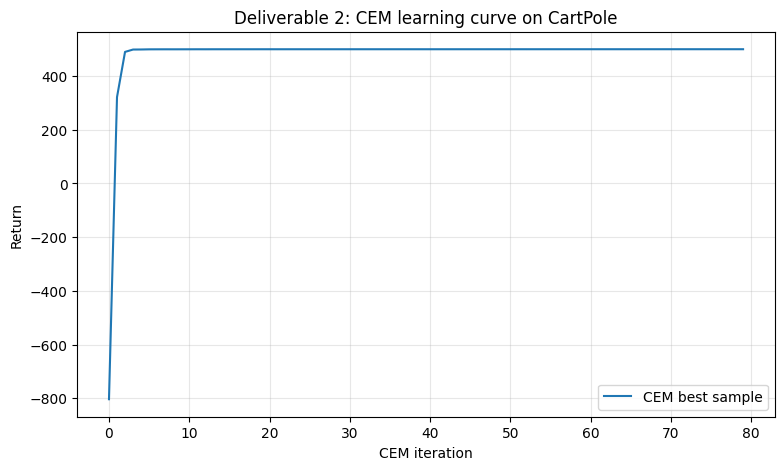

Approximate environment steps: 20,480,000


In [ ]:
# Plot the best CEM return from each iteration
plt.figure(figsize=(9, 5))
plt.plot(np.asarray(cem_history), label="CEM best sample")
plt.xlabel("CEM iteration")
plt.ylabel("Return")
plt.title("Deliverable 2: CEM learning curve on CartPole")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Estimate the sample cost
population = 512
print(f"Approximate environment steps: {len(cem_history) * population * H:,}")

## Short analysis for the report

CEM works well on CartPole because the policy parameter dimension is small. It becomes harder to scale to locomotion because a high-dimensional policy needs a much larger population to estimate a useful elite distribution, so most samples are wasted and the covariance/standard-deviation update becomes noisy.


In [ ]:
# Render a trained CartPole policy by replaying its MJX trajectory in CPU MuJoCo
def render_policy_video(params, obs_mean, obs_std, title, fps=30):
    # First generate the trajectory with the learned feedback policy
    reward, states = rollout_policy(params, obs_mean, obs_std, cart_start)
    states = np.asarray(states)

    # Create a MuJoCo renderer for RGB frames
    renderer = mujoco.Renderer(cart_model, height=480, width=640)
    frames = []
    render_step = max(1, int((1 / fps) / cart_model.opt.timestep))

    # Copy each saved MJX state into CPU MuJoCo and render video frames
    cpu_data = mujoco.MjData(cart_model)
    for i in range(H):
        if i % render_step == 0:
            cpu_data.qpos[:] = states[i, :2]
            cpu_data.qvel[:] = states[i, 2:]
            mujoco.mj_forward(cart_model, cpu_data)
            renderer.update_scene(cpu_data)
            frames.append(renderer.render().copy())

    renderer.close()
    print(f"{title} return: {float(reward):.2f}")
    media.show_video(frames, fps=fps)


# Show the CEM policy video
render_policy_video(cem_params, ZERO_MEAN, UNIT_STD, "CEM CartPole policy")

CEM CartPole policy return: 499.45


This browser does not support the video tag.


#Task 2.3: Attempt to apply your CEM implementation to the Humanoid environment.
Document the computational bottlenecks, convergence issues, and performance limitations.

(available in Deliverables 3 & 4)